# Step 3 - filter processed trajectories:
Input: data from step 2 

Filter for when there are 21 days spent in a location as “used”
export
Output:  'processed_trajectories_21dfilter.csv'

This step reduces the number of drifters from 1583 to 996

In [9]:
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import os

from shapely.geometry import Point, Polygon as ShapelyPolygon
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
import utils  # Importing the utils module
import numpy as np

In [2]:
# File paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/data/'
output_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/processed_data/'
save_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/retention-plots'
fig_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/'

# List of presence columns
presence_columns = ['BS', 'GERL', 'GP', 'MB2', 'outside']

# Load the unfiltered data
file = output_path + 'processed_trajectories_wpresence_unfiltered.csv'
processed_df = pd.read_csv(file)
print('Raw number of larvae:', processed_df.larval_id.nunique())


Raw number of larvae: 16658


In [3]:
# Group by relevant identifiers and sum the presence counts
grouped_df = processed_df.groupby(
    ['hypothesis', 'start_year', 'IDL_loc', 'larval_id']
)[presence_columns].sum().reset_index()

print('Number of larvae after grouping:', grouped_df.larval_id.nunique())

Number of larvae after grouping: 16658


## Retention Sensitivity

In [4]:
# Data for start years
start_years = {
    2016: {
        'label': 'sy 2016',
        'marker': 'o',  # Circle
        'color': '#648fff'
    },
    2017: {
        'label': 'sy 2017',
        'marker': 's',  # Square
        'color': '#dc267f'
    },
    2018: {
        'label': 'sy 2018',
        'marker': '^',  # Triangle up
        'color': '#ffb000'
    }
}

In [5]:
# Define a dictionary mapping hypothesis codes to names
hypothesis_names = {
    'h_null': 'ocean-only',
    'h_ice': 'sea-ice',
    'h_dvm': 'modified-DVM',
    'h_size': 'embryo-size'
}

In [10]:
# Define updated retention intervals
retention_intervals = [
    (1, 7), (8, 14), (15, 21), (22, 28), 
    (29, 35), (36, 42), (43, float('inf'))
]


In [11]:
import importlib
import utils  # Importing the utils module

In [ ]:
# Initialize a DataFrame to store the summary results
summary_results = pd.DataFrame(columns=['hypothesis', 'start_year', 'IDL_loc', 'Interval', 'Num_Drifters'])

# Analyze drifters retained within each interval, grouped by hypothesis, year, and location
for (hypothesis, start_year, IDL_loc), loc_group in grouped_df.groupby(['hypothesis', 'start_year', 'IDL_loc']):
    for lower, upper in retention_intervals:
        interval_df = loc_group[(loc_group[IDL_loc] >= lower) & (loc_group[IDL_loc] <= upper)]
        num_drifters = interval_df['larval_id'].nunique()

        summary_results = pd.concat(
            [summary_results, pd.DataFrame({
                'hypothesis': [hypothesis],
                'start_year': [start_year],
                'IDL_loc': [IDL_loc],
                'Interval': [f'{lower}-{int(upper) if upper != float("inf") else "42+"}'],
                'Num_Drifters': [num_drifters]
            })],
            ignore_index=True
        )
summary_results


## Visualize

In [21]:
def plot_4_panel_vertical(hypothesis, save_path=None):
    # Create a 1x4 grid
    fig, axes = plt.subplots(4, 1, figsize=(6, 12), sharex=True, sharey=True)

    # Get ordered locations
    ordered_locations = sorted(locations.keys(), key=lambda x: location_order[x])

    for i, location in enumerate(ordered_locations):
        subset = grouped_df[
            (grouped_df['IDL_loc'] == location) & 
            (grouped_df['hypothesis'] == hypothesis)
        ]

        melted = subset.melt(
            id_vars=['hypothesis', 'start_year', 'IDL_loc', 'larval_id'], 
            value_vars=presence_columns[:-1],
            var_name='Location', 
            value_name='Retention_Days'
        )

        melted = melted[(melted['Location'] == location) & (melted['Retention_Days'] >= 0)]
        melted['start_year'] = melted['start_year'].astype(str)

        sns.violinplot(
            data=melted, 
            x='start_year', 
            y='Retention_Days', 
            hue='start_year',
            palette={'2016': '#648fff', '2017': '#dc267f', '2018': '#ffb000'},
            cut=0,
            ax=axes[i]
        )
        axes[i].axhline(y=21, color='black', linestyle='--', linewidth=0.5, alpha=0.75)

        # Use location labels for subplot titles
        location_label = location_labels.get(location, location)
        axes[i].set_title(f'Retention in {location_label}', fontsize=12)

        # Customize axis labels
        axes[i].set_xlabel('')  # No X label for inner rows
        if i == 3:  # Last row gets the X-axis label
            axes[i].set_xlabel('Start Year', fontsize=12)
        axes[i].set_ylabel('Retention Days', fontsize=10)

        # Add grid lines
        axes[i].set_axisbelow(True)
        axes[i].grid(True, linestyle='--', linewidth=0.7, color='lavender')

        # Safely remove the legend if it exists
        legend = axes[i].get_legend()
        if legend:
            legend.remove()

    # Add a shared title
    hypothesis_label = hypothesis_labels.get(hypothesis, hypothesis)
    fig.suptitle(f'Distribution of Retention Durations for "{hypothesis_label}" Simulation', fontsize=14, y=0.93)

    # # Shared legend outside the plots
    # handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=3, title='Start Year')

    plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust for title and legend

    # Save the plot
    if save_path:
        filename = f'{hypothesis}_retention_4_panel_vertical.png'
        plt.savefig(os.path.join(save_path, filename), bbox_inches='tight', dpi=300)
    plt.show()

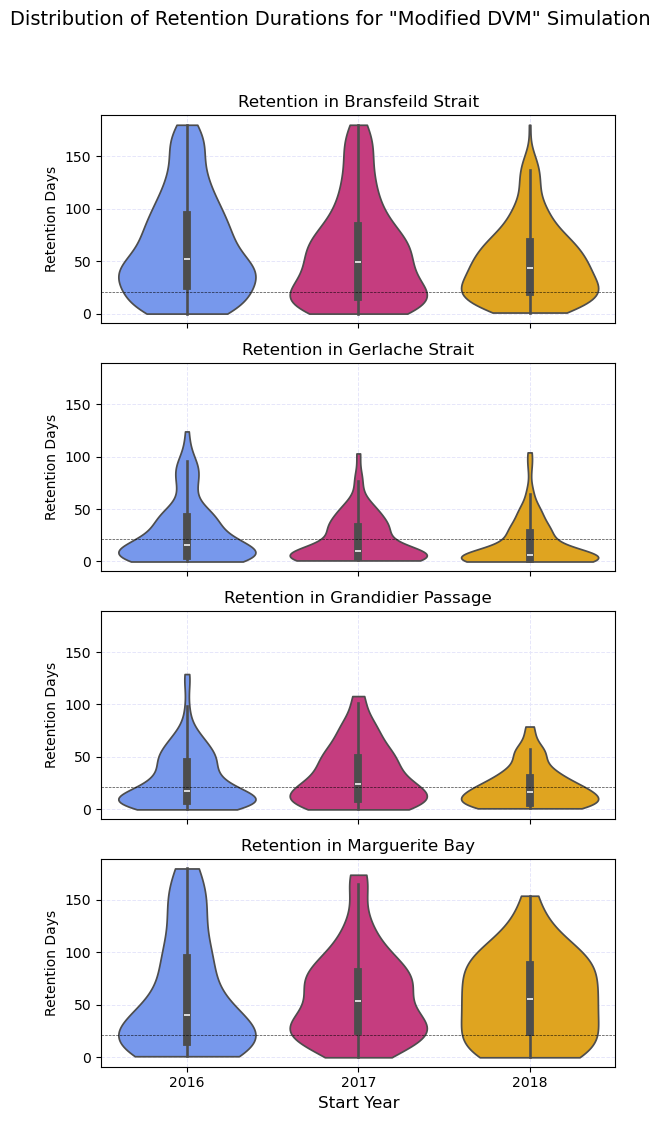

In [22]:
fig_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/'

plot_4_panel_vertical('h_dvm')#, save_path=fig_path)

In [44]:
def plot_2_column_comparison(hypotheses, save_path=None):
    fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, sharey=True)

    # Get ordered locations
    ordered_locations = sorted(locations.keys(), key=lambda x: location_order[x])

    for col, hypothesis in enumerate(hypotheses):
        for row, location in enumerate(ordered_locations):
            ax = axes[row, col]
            subset = grouped_df[
                (grouped_df['IDL_loc'] == location) & 
                (grouped_df['hypothesis'] == hypothesis)
            ]

            melted = subset.melt(
                id_vars=['hypothesis', 'start_year', 'IDL_loc', 'larval_id'], 
                value_vars=presence_columns[:-1],
                var_name='Location', 
                value_name='Retention_Days'
            )

            melted = melted[(melted['Location'] == location) & (melted['Retention_Days'] >= 0)]

            # Add season information to the x-axis
            melted['Season'] = melted['start_year'].astype(int).apply(lambda x: f"{x}-{x + 1}")

            sns.violinplot(
                data=melted, 
                x='Season', 
                y='Retention_Days', 
                hue='start_year',
                palette={2016: '#648fff', 2017: '#dc267f', 2018: '#ffb000'},
                cut=0,
                ax=ax
            )
            ax.axhline(y=21, color='black', linestyle='--', linewidth=0.5, alpha=0.75)

            # Add subplot titles
            location_label = location_labels.get(location, location)
            hypothesis_label = hypothesis_labels.get(hypothesis, hypothesis)
            if row == 0:
                ax.set_title(f'{hypothesis_label} Simulation', fontsize=14, pad=10)

            # Set Y-axis labels
            if col == 0:  # First column: Add Y-axis label
                ax.set_ylabel(f'Retention in {location_label} NG (days)', fontsize=12)
            else:  # Second column: No Y label
                ax.set_ylabel('')

            # Add X-axis labels as years
            ax.set_xlabel('')  # Individual x-axis labels are not added here
            ax.tick_params(axis='x', labelsize=10, rotation=45)

            # Add grid lines
            ax.set_axisbelow(True)
            ax.grid(True, linestyle='--', linewidth=0.7, color='lavender')

            # Safely remove the legend
            legend = ax.get_legend()
            if legend:
                legend.remove()

    # Add shared axis labels
    fig.text(0.5, 0.04, 'Season', ha='center', fontsize=16)  # Shared x-axis label

    # Adjust layout to add spacing between columns and rows
    plt.subplots_adjust(wspace=0.2, hspace=0.5)

    # Save the plot
    if save_path:
        filename = f'Retention_{hypotheses[0]}_{hypotheses[1]}_comparison.png'
        plt.savefig(os.path.join(save_path, filename), bbox_inches='tight', dpi=300)
    plt.show()

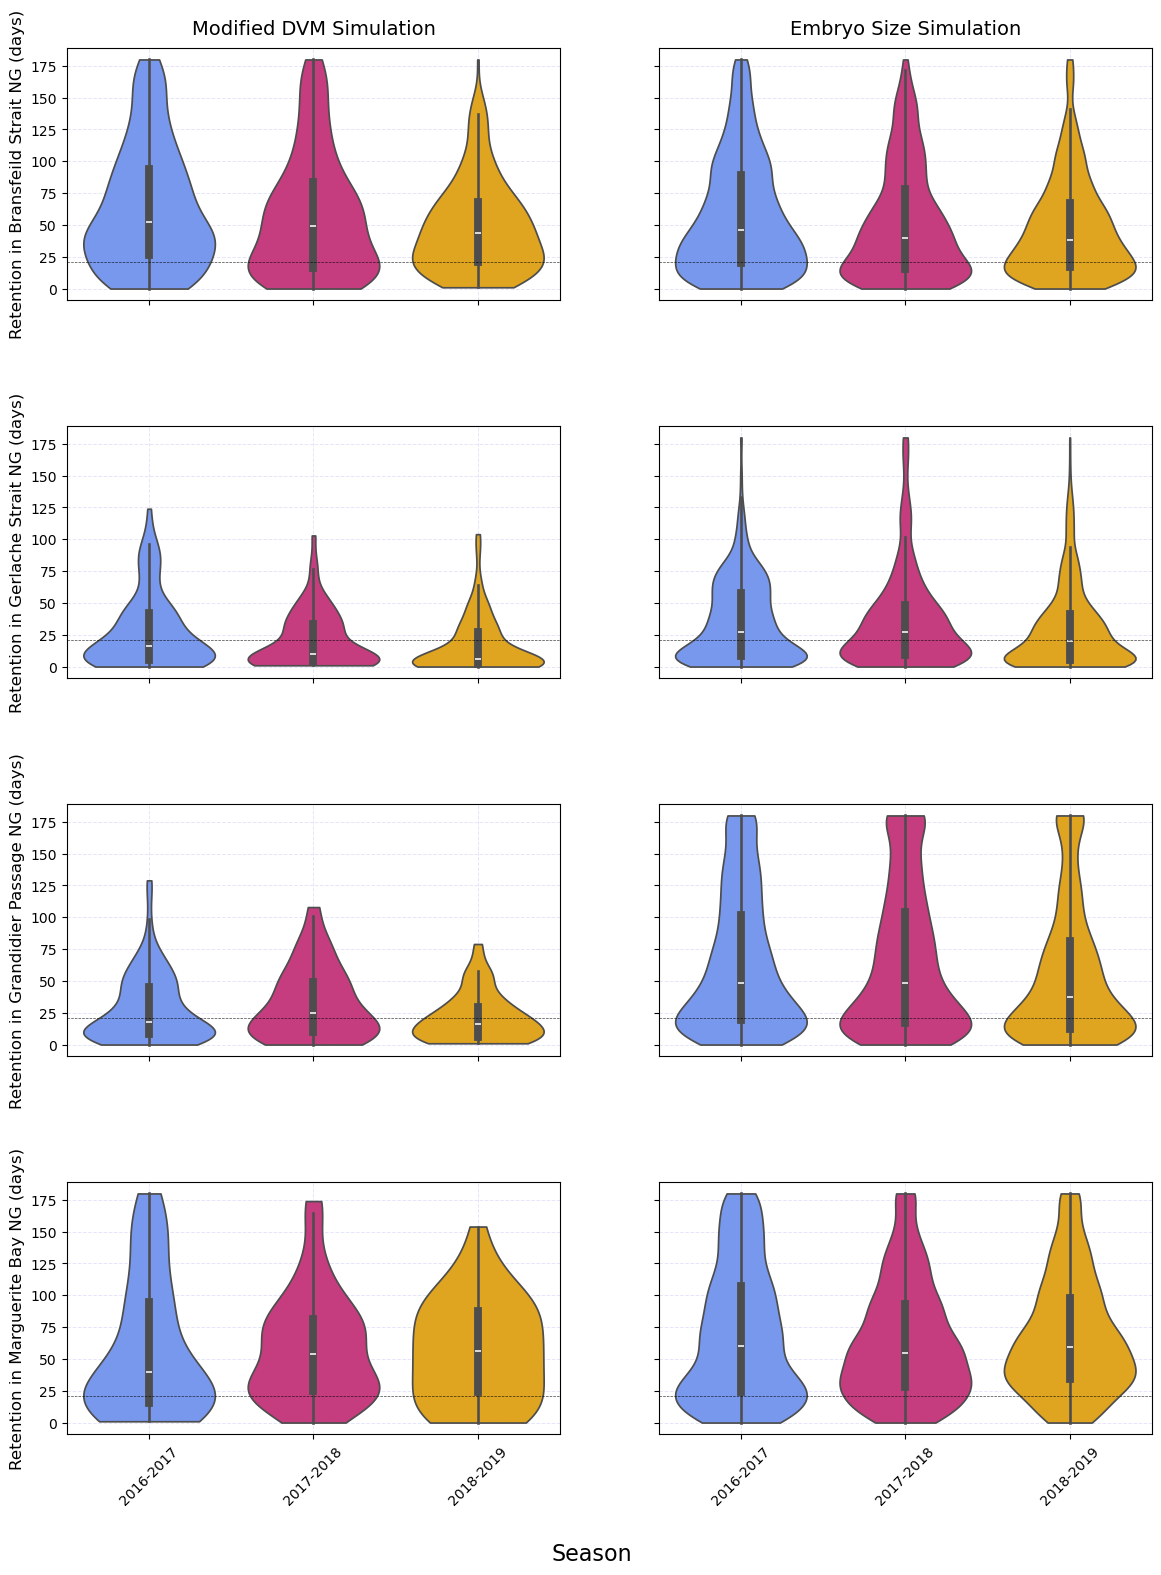

In [45]:
fig_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/manuscript-versions/'

plot_2_column_comparison(['h_dvm', 'h_size'], save_path=fig_path)

In [46]:
def plot_2_column_comparison(hypotheses, save_path=None):
    fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, sharey=True)

    # Get ordered locations
    ordered_locations = sorted(locations.keys(), key=lambda x: location_order[x])

    for col, hypothesis in enumerate(hypotheses):
        for row, location in enumerate(ordered_locations):
            ax = axes[row, col]
            subset = grouped_df[
                (grouped_df['IDL_loc'] == location) & 
                (grouped_df['hypothesis'] == hypothesis)
            ]

            melted = subset.melt(
                id_vars=['hypothesis', 'start_year', 'IDL_loc', 'larval_id'], 
                value_vars=presence_columns[:-1],
                var_name='Location', 
                value_name='Retention_Days'
            )

            melted = melted[(melted['Location'] == location) & (melted['Retention_Days'] >= 0)]

            # Add season information to the x-axis
            melted['Season'] = melted['start_year'].astype(int).apply(lambda x: f"{x}-{x + 1}")

            sns.violinplot(
                data=melted, 
                x='Season', 
                y='Retention_Days', 
                hue='start_year',
                palette={2016: '#648fff', 2017: '#dc267f', 2018: '#ffb000'},
                cut=0,
                ax=ax
            )
            ax.axhline(y=21, color='black', linestyle='--', linewidth=0.5, alpha=0.75)

            # Add subplot titles
            location_label = location_labels.get(location, location)
            hypothesis_label = hypothesis_labels.get(hypothesis, hypothesis)
            if row == 0:
                ax.set_title(f'{hypothesis_label} Simulation', fontsize=14, pad=10)

            # Set Y-axis labels
            if col == 0:  # First column: Add Y-axis label
                ax.set_ylabel(f'Retention in {location_label} NG (days)', fontsize=12)
            else:  # Second column: No Y label
                ax.set_ylabel('')

            # Add X-axis labels as years
            ax.set_xlabel('')  # Individual x-axis labels are not added here
            ax.tick_params(axis='x', labelsize=10, rotation=45)

            # Add grid lines
            ax.set_axisbelow(True)
            ax.grid(True, linestyle='--', linewidth=0.7, color='lavender')

            # Safely remove the legend
            legend = ax.get_legend()
            if legend:
                legend.remove()

    # Add shared axis labels
    fig.text(0.5, 0.04, 'Season', ha='center', fontsize=16)  # Shared x-axis label

    # Adjust layout to add spacing between columns and rows
    plt.subplots_adjust(wspace=0.2, hspace=0.5)

    # Save the plot
    if save_path:
        filename = f'Retention_{hypotheses[0]}_{hypotheses[1]}_comparison.png'
        plt.savefig(os.path.join(save_path, filename), bbox_inches='tight', dpi=300)
    plt.show()

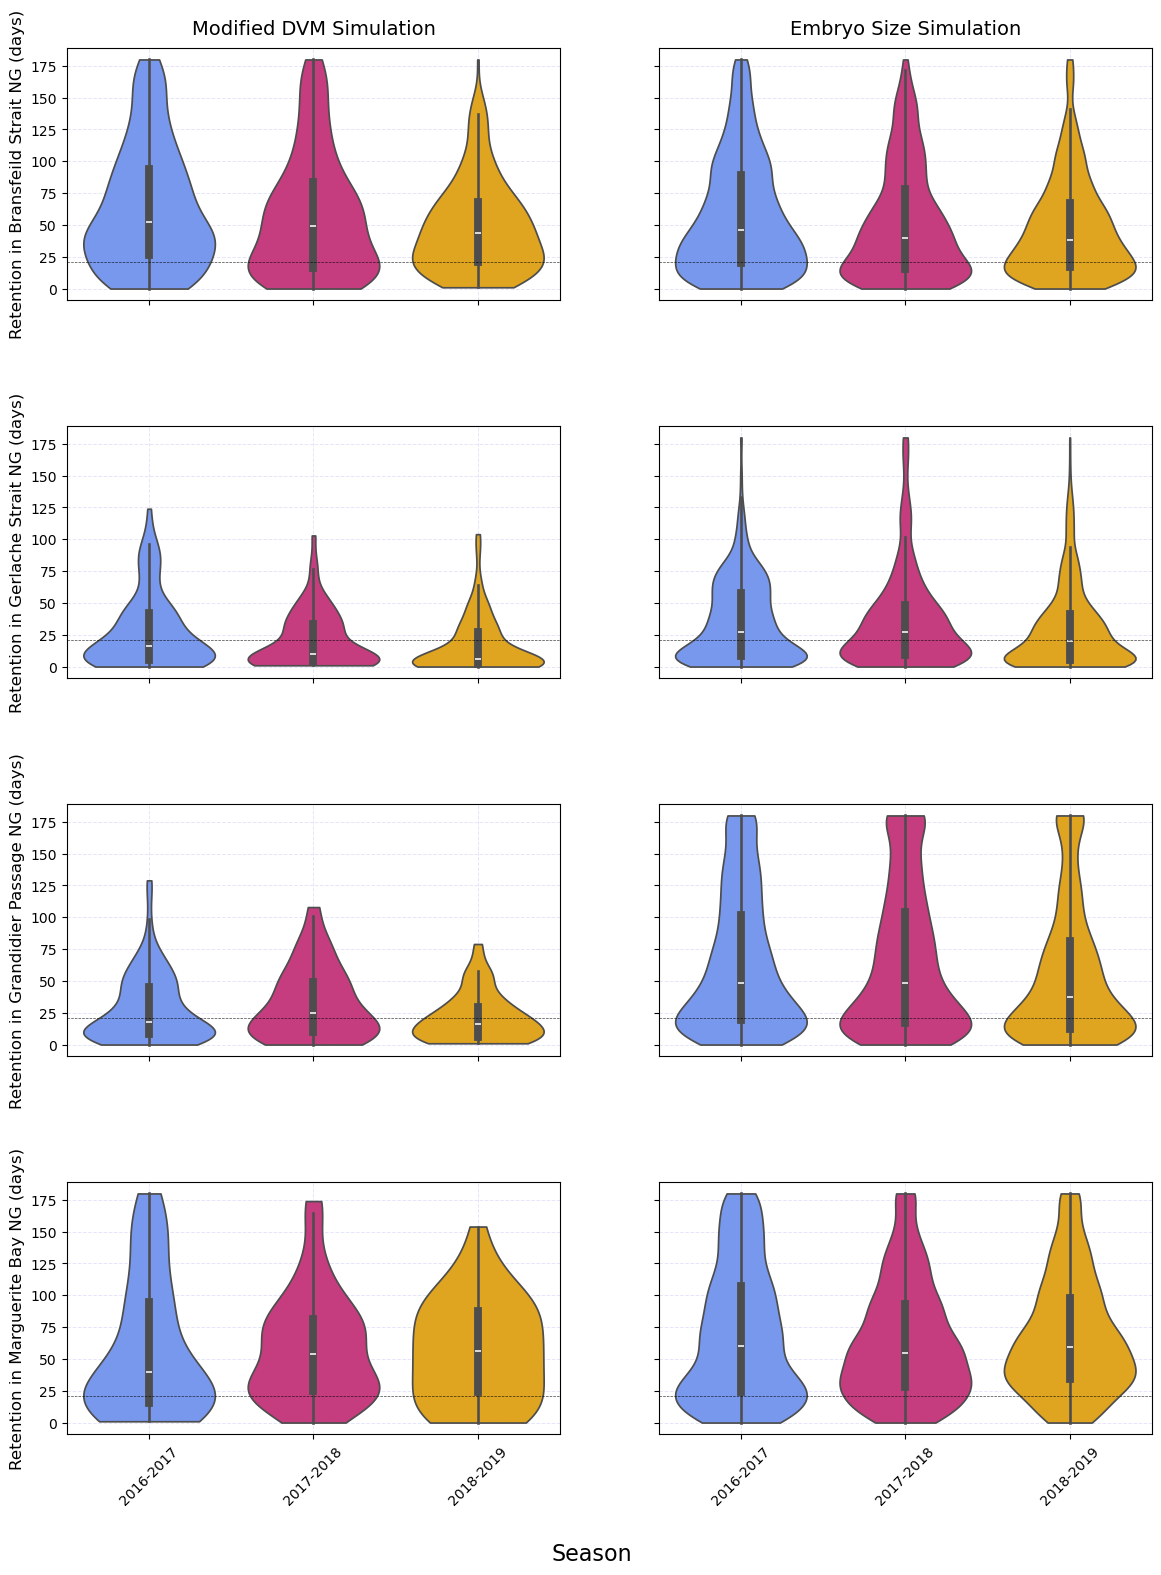

In [47]:
plot_2_column_comparison(['h_dvm', 'h_size'])#, save_path=fig_path)

In [ ]:
# Thresholds Bar Plots
# Plot and Save: Loop over Locations and Hypotheses
def plot_and_save(location, hypothesis):
    subset = summary_results[
        (summary_results['IDL_loc'] == location) & 
        (summary_results['hypothesis'] == hypothesis)
    ]
    # Ensure the custom palette aligns with the years in the data
    custom_palette = {
        2016: '#648fff',  # Blue
        2017: '#dc267f',  # Pink
        2018: '#ffb000'   # Orange
    }

    plt.figure(figsize=(8, 4))
    
    # Use seaborn barplot with custom color palette for start years
    sns.barplot(
        data=subset, 
        x='Interval', 
        y='Num_Drifters', 
        hue='start_year', 
        palette=custom_palette
    )

    # Add lavender horizontal grid lines
    plt.gca().yaxis.grid(True, linestyle='--', linewidth=0.7, color='lavender')
    plt.gca().set_axisbelow(True)  # Ensure grid lines are below bars

    # Set plot title and labels
    plt.title(f'Retention Across Intervals for {hypothesis} in {location}')
    plt.ylabel('Number of Drifters')
    plt.xlabel('Retention Interval (Days)')
    plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend position
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save the plot as a PNG file
    filename = f'{hypothesis}_{location}_retention.png'
    plt.savefig(os.path.join(fig_path, filename))
    plt.show()  # Close the plot to free up memory

# Loop through all locations and hypotheses, generate, and save plots
locations = ['BS', 'GERL', 'GP', 'MB2']
hypotheses = summary_results['hypothesis'].unique()

for location in locations:
    for hypothesis in hypotheses:
        plot_and_save(location, hypothesis)


In [ ]:
# Plot and Save: Distribution of Retention Durations by Year
def plot_distribution_by_year(location, hypothesis):
    subset = grouped_df[
        (grouped_df['IDL_loc'] == location) & 
        (grouped_df['hypothesis'] == hypothesis)
    ]

    # Melt the data to plot retention days in a single column
    melted = subset.melt(
        id_vars=['hypothesis', 'start_year', 'IDL_loc', 'larval_id'], 
        value_vars=presence_columns[:-1],  # Exclude 'outside'
        var_name='Location', 
        value_name='Retention_Days'
    )

    # Filter for the selected location and non-negative retention days
    melted = melted[(melted['Location'] == location) & (melted['Retention_Days'] >= 0)]

    # Convert start_year to string for palette mapping
    melted['start_year'] = melted['start_year'].astype(str)

    plt.figure(figsize=(8, 4))

    # Violin plot with hue mapped to start_year
    sns.violinplot(
        data=melted, 
        x='start_year', 
        y='Retention_Days', 
        hue='start_year',  # Use hue for color distinction
        palette={
            '2016': '#648fff', 
            '2017': '#dc267f', 
            '2018': '#ffb000'
        },
        cut=0,  # Prevents the KDE from extending beyond the data range
        legend=False  # Disable default legend to avoid duplication
    )
    # Set y-axis limit to ensure consistency across plots
    plt.ylim(-5, 200)
    # Add a horizontal line at 21 days
    plt.axhline(y=21, color='black', linestyle='--', linewidth=0.5,alpha=0.75, label='21-day threshold')

    # Add lavender horizontal grid lines
    plt.gca().yaxis.grid(True, linestyle='--', linewidth=0.7, color='lavender')
    plt.gca().set_axisbelow(True)

    # Set plot title and labels
    plt.title(f'Distribution of Retention Durations for {hypothesis} in {location}')
    plt.ylabel('Retention Duration (Days)')
    plt.xlabel('Start Year')
    plt.tight_layout()

    # Save the plot as a PNG file
    filename = f'{hypothesis}_{location}_retention_distribution-violins.png'
    plt.savefig(os.path.join(save_path, filename))
    plt.show()  # Close the plot to free up memory


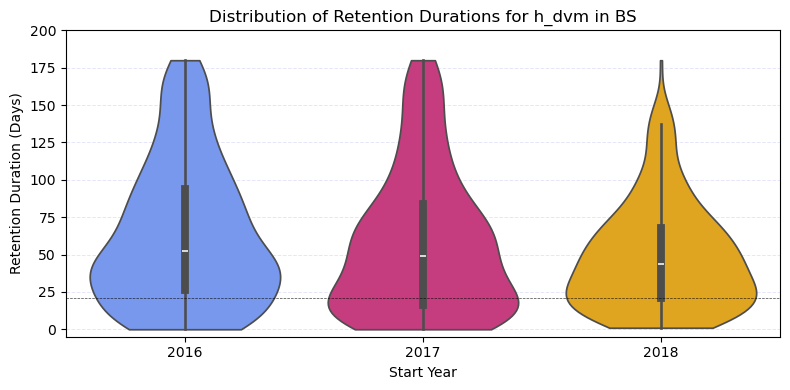

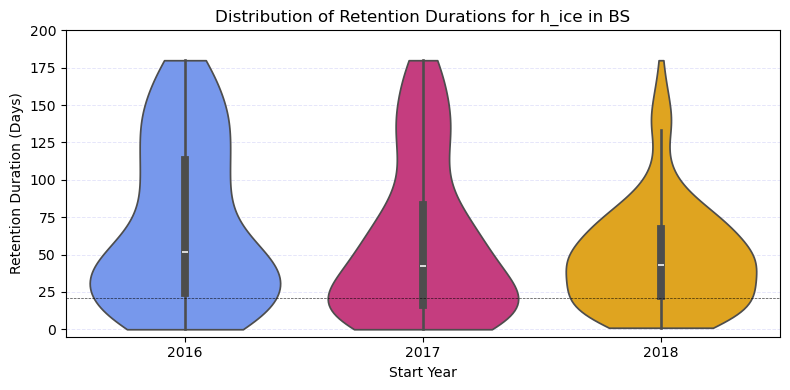

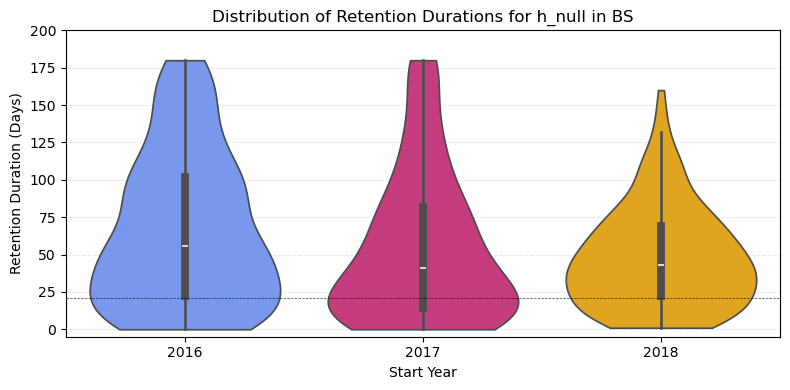

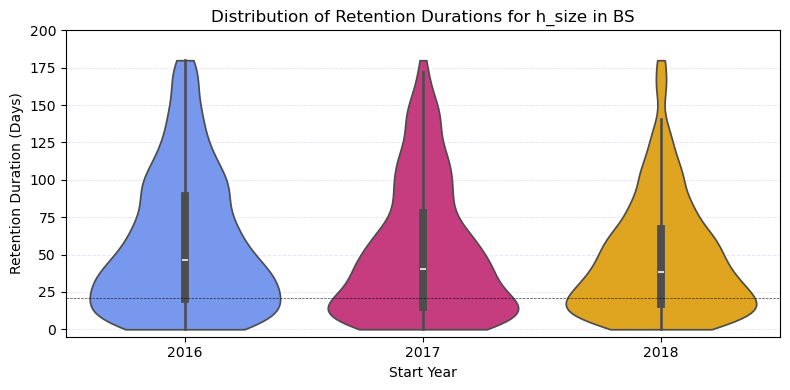

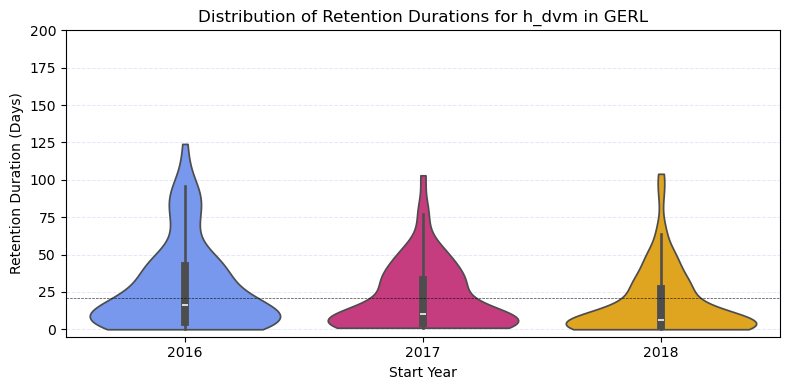

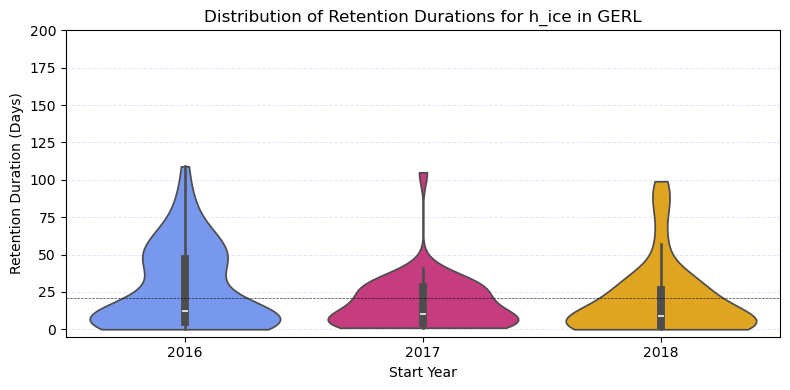

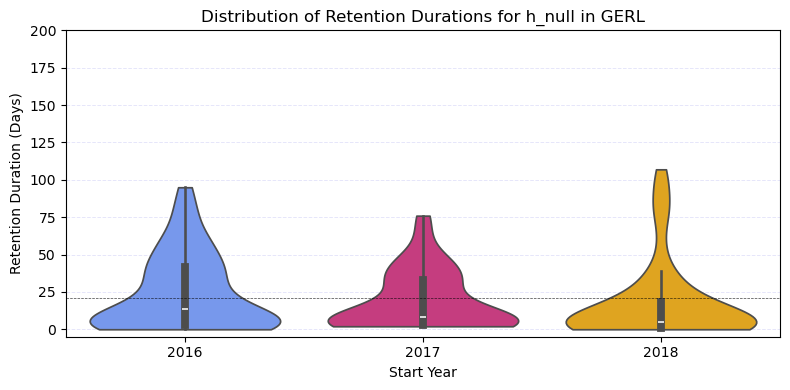

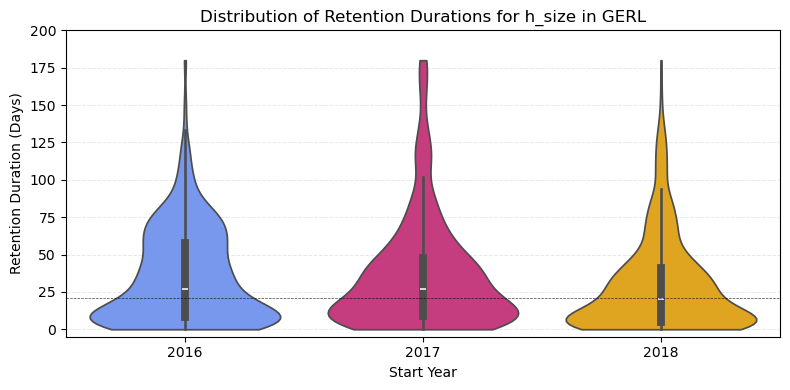

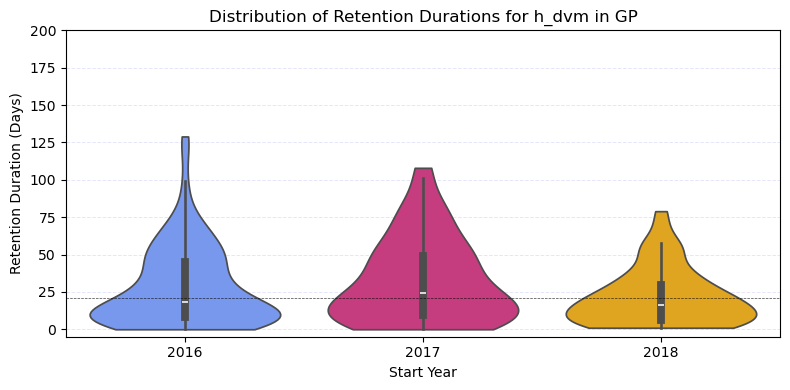

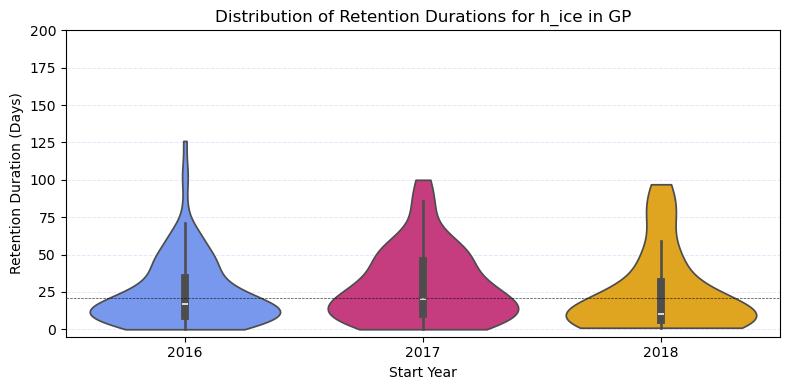

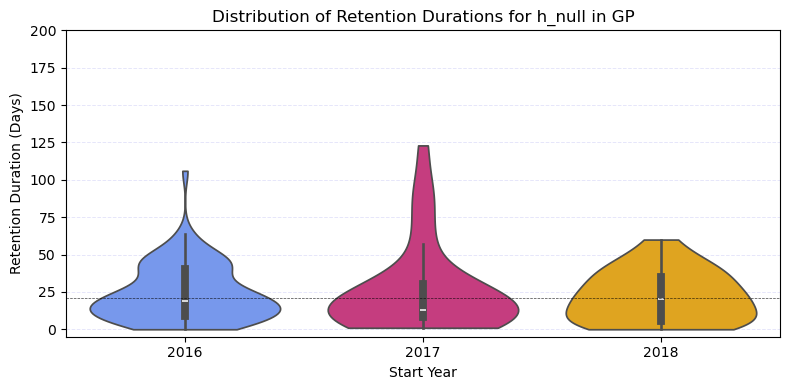

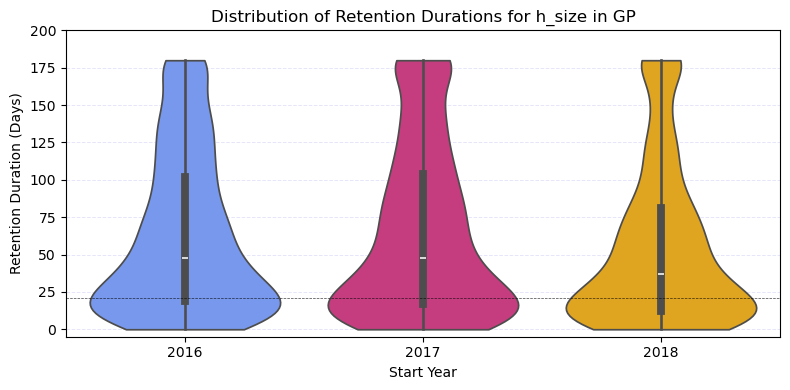

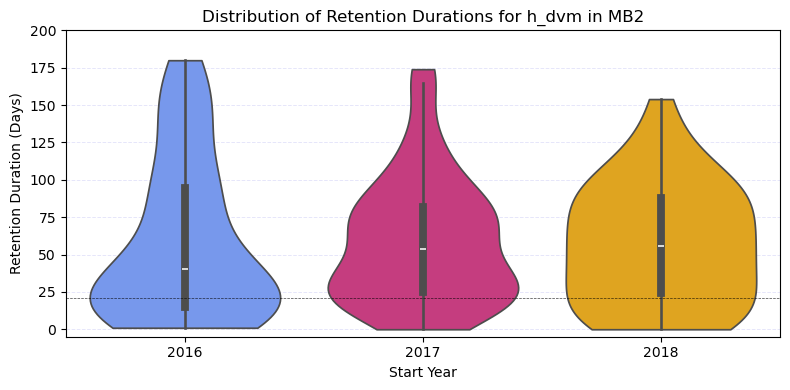

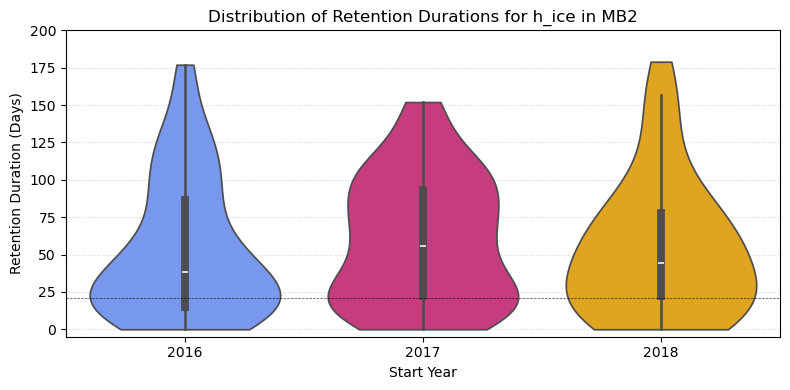

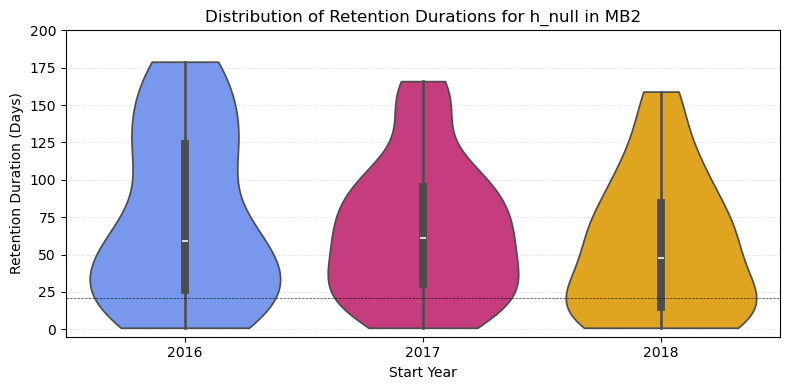

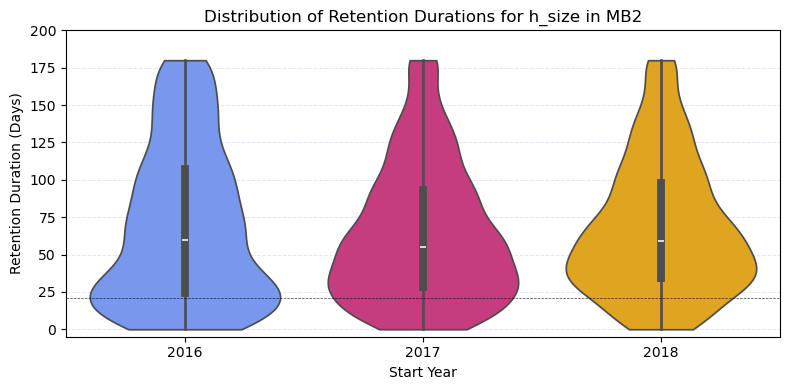

In [12]:
# Loop through all locations and hypotheses, generate, and save plots
locations = ['BS', 'GERL', 'GP', 'MB2']
hypotheses = grouped_df['hypothesis'].unique()

for location in locations:
    for hypothesis in hypotheses:
        plot_distribution_by_year(location, hypothesis)

In [36]:
def plot_4_panel(hypothesis):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    locations = ['BS', 'GERL', 'GP', 'MB2']
    axes = axes.flatten()  # Flatten for easy iteration

    for i, location in enumerate(locations):
        subset = grouped_df[
            (grouped_df['IDL_loc'] == location) & 
            (grouped_df['hypothesis'] == hypothesis)
        ]

        melted = subset.melt(
            id_vars=['hypothesis', 'start_year', 'IDL_loc', 'larval_id'], 
            value_vars=presence_columns[:-1],
            var_name='Location', 
            value_name='Retention_Days'
        )

        melted = melted[(melted['Location'] == location) & (melted['Retention_Days'] >= 0)]
        melted['start_year'] = melted['start_year'].astype(str)

        sns.violinplot(
            data=melted, 
            x='start_year', 
            y='Retention_Days', 
            hue='start_year',
            palette={'2016': '#648fff', '2017': '#dc267f', '2018': '#ffb000'},
            cut=0,
            ax=axes[i]
        )
        axes[i].axhline(y=21, color='black', linestyle='--', linewidth=0.5, alpha=0.75)
        
        # Customize subplot title
        axes[i].set_title(f'Retention in {location}', fontsize=12)#, fontweight='bold')
        
        # Customize axis labels
        axes[i].set_xlabel('Start Year', fontsize=10)
        axes[i].set_ylabel('Days', fontsize=10)

        # Make grid lines appear behind the data
        axes[i].set_axisbelow(True)
        axes[i].grid(True, linestyle='--', linewidth=0.7, color='lavender')

        # Safely remove the legend if it exists
        legend = axes[i].get_legend()
        if legend:
            legend.remove()

    # Use the descriptive name for the hypothesis in the title
    hypothesis_name = hypothesis_names.get(hypothesis, hypothesis)  # Default to the code if not found
    fig.suptitle(f'Distribution of Retention Durations for Simulation: {hypothesis_name}', fontsize=14)#, fontweight='bold')
    fig.supxlabel('Start Year', fontsize=12)
    fig.supylabel('Retention Duration (Days)', fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout for title
    plt.savefig(f'{hypothesis}_4_panel_plot.png')
    plt.show()

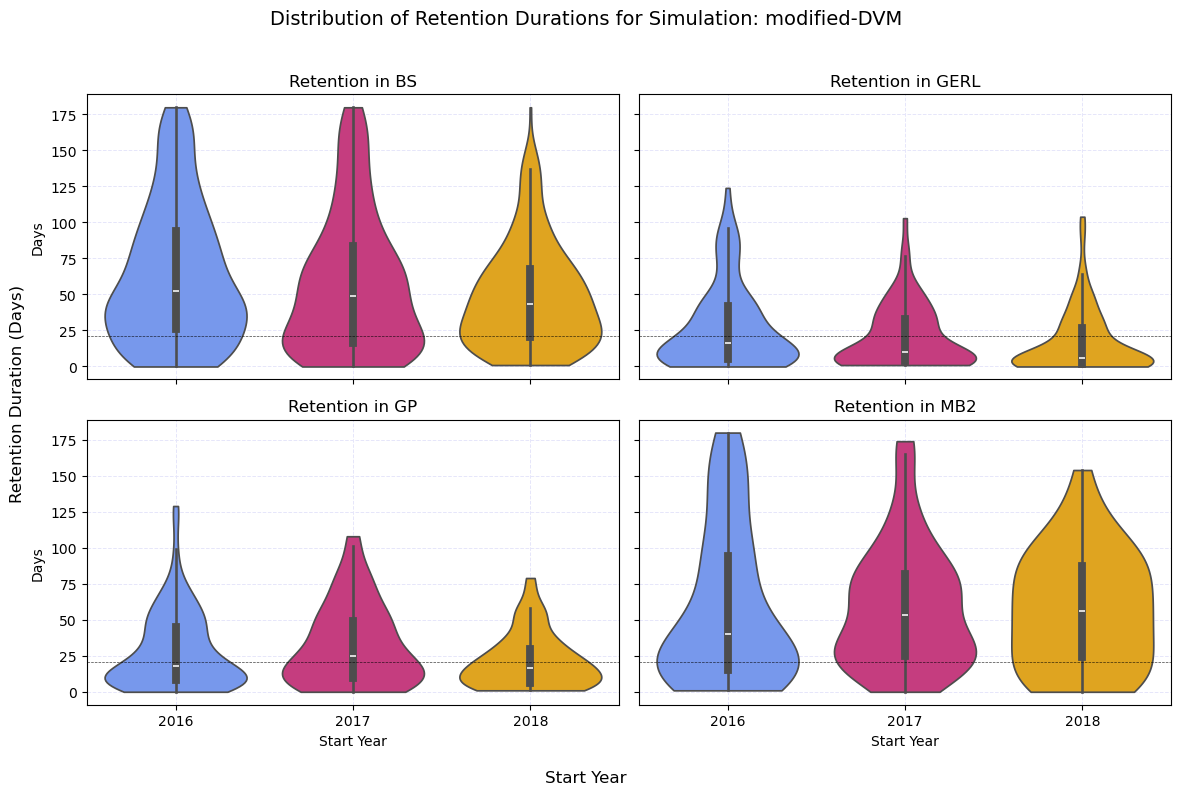

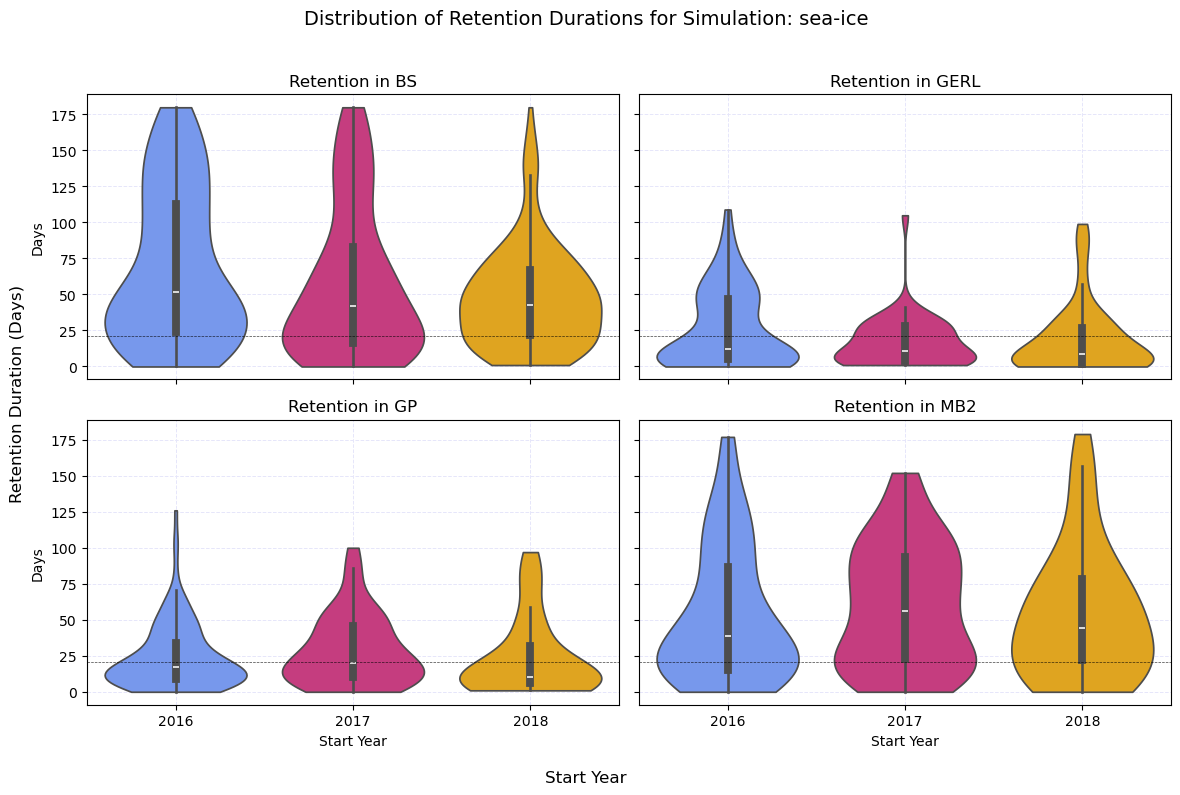

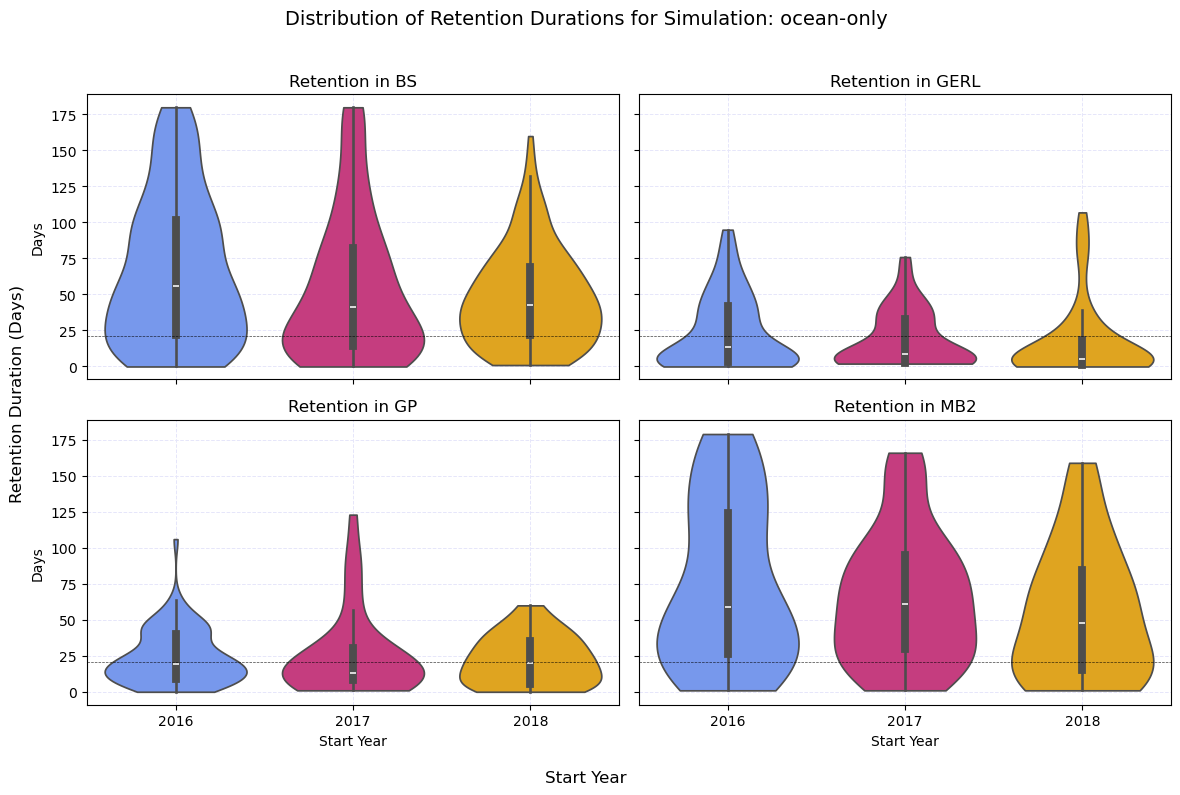

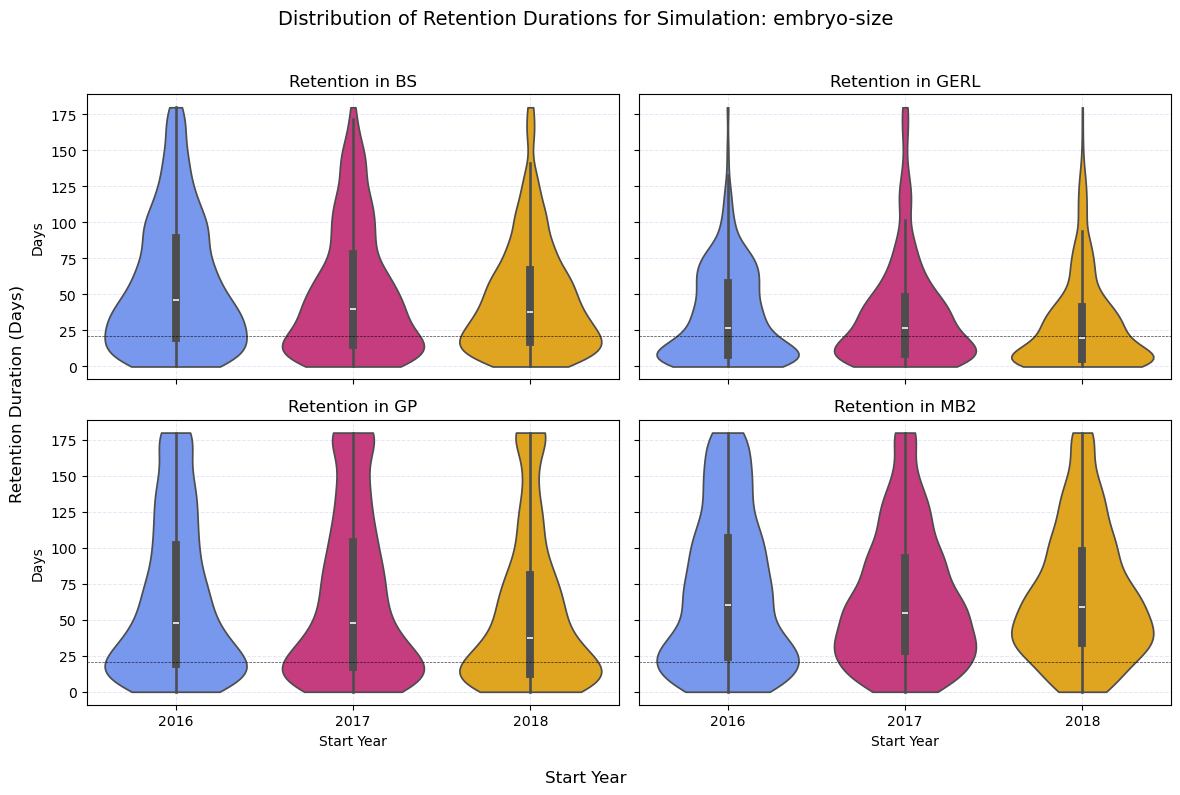

In [37]:
# Loop through all hypotheses
for hypothesis in hypotheses:
    plot_4_panel(hypothesis)

In [14]:
# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}

locations = utils.locations

location_labels = {key: value['label'] for key, value in locations.items()}
location_order = {key: value['order'] for key, value in locations.items()}

In [78]:
def plot_4_panel(hypothesis):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    
    # Get ordered locations
    ordered_locations = sorted(locations.keys(), key=lambda x: location_order[x])
    axes = axes.flatten()  # Flatten for easy iteration

    for i, location in enumerate(ordered_locations):
        subset = grouped_df[
            (grouped_df['IDL_loc'] == location) & 
            (grouped_df['hypothesis'] == hypothesis)
        ]

        melted = subset.melt(
            id_vars=['hypothesis', 'start_year', 'IDL_loc', 'larval_id'], 
            value_vars=presence_columns[:-1],
            var_name='Location', 
            value_name='Retention_Days'
        )

        melted = melted[(melted['Location'] == location) & (melted['Retention_Days'] >= 0)]
        melted['start_year'] = melted['start_year'].astype(str)

        sns.violinplot(
            data=melted, 
            x='start_year', 
            y='Retention_Days', 
            hue='start_year',
            palette={'2016': '#648fff', '2017': '#dc267f', '2018': '#ffb000'},
            cut=0,
            ax=axes[i]
        )
        axes[i].axhline(y=21, color='black', linestyle='--', linewidth=0.5, alpha=0.75)
        
        # Use location and hypothesis labels for the subplot title
        hypothesis_label = hypothesis_labels.get(hypothesis, hypothesis)
        location_label = location_labels.get(location, location)
        axes[i].set_title(f'Retention in {location_label} - "{hypothesis_label}" simulation', fontsize=12)
        
        # Customize axis labels
        axes[i].set_xlabel('Start Year', fontsize=10)
        axes[i].set_ylabel('Days Retained', fontsize=10)

        # Make grid lines appear behind the data
        axes[i].set_axisbelow(True)
        axes[i].grid(True, linestyle='--', linewidth=0.7, color='lavender')

        # Safely remove the legend if it exists
        legend = axes[i].get_legend()
        if legend:
            legend.remove()

    # Use the descriptive name for the hypothesis
    hypothesis_name = hypotheses_name.get(hypothesis, hypothesis)
    fig.suptitle(f'Distribution of Retention Durations for "{hypothesis_label}" simulation', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout for title
    # Save the plot as a PNG file
    filename = f'{hypothesis}_{location}_retention_4_panel_plot.png'
    plt.savefig(os.path.join(fig_path, filename))
    
    plt.show()

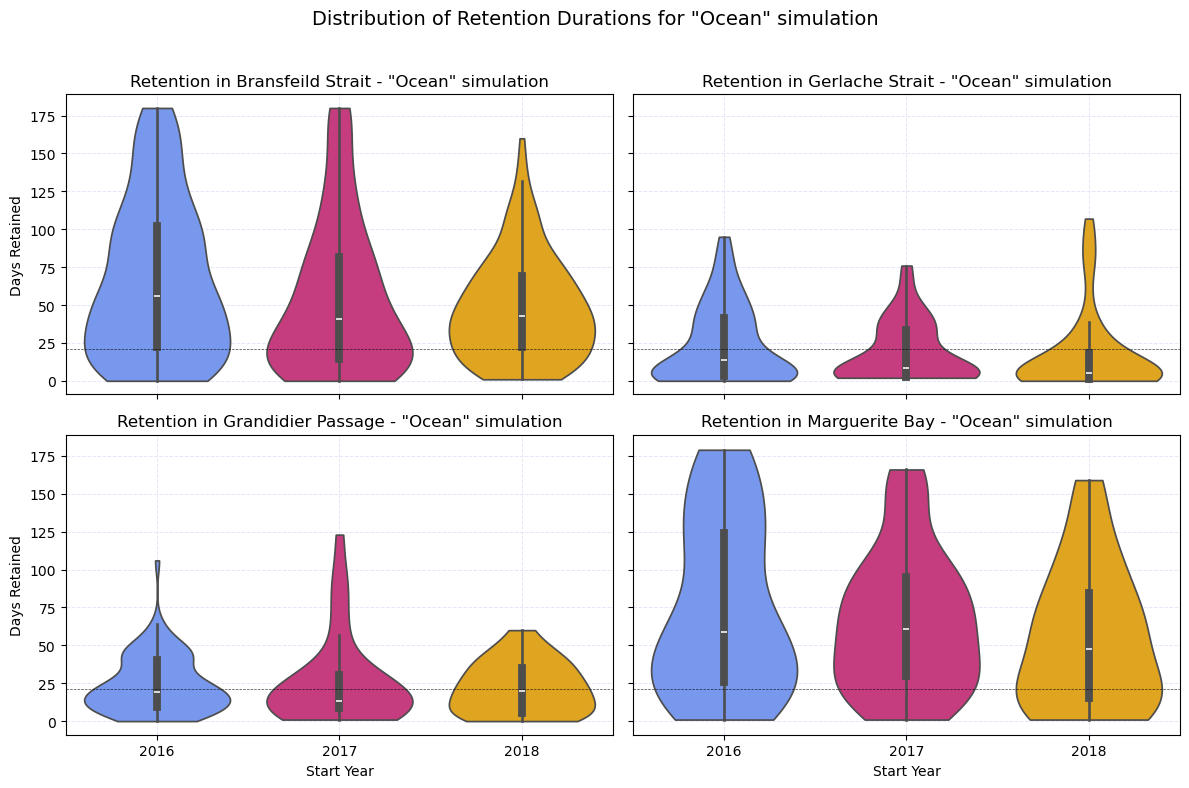

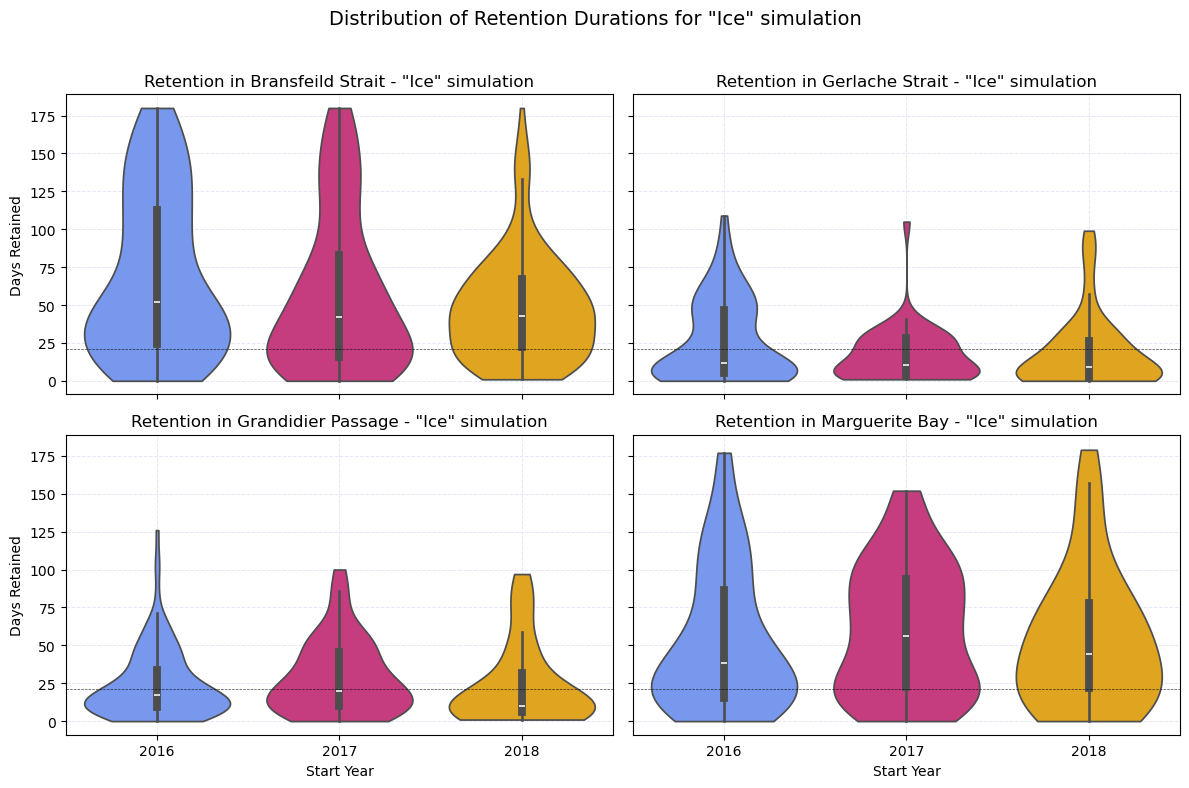

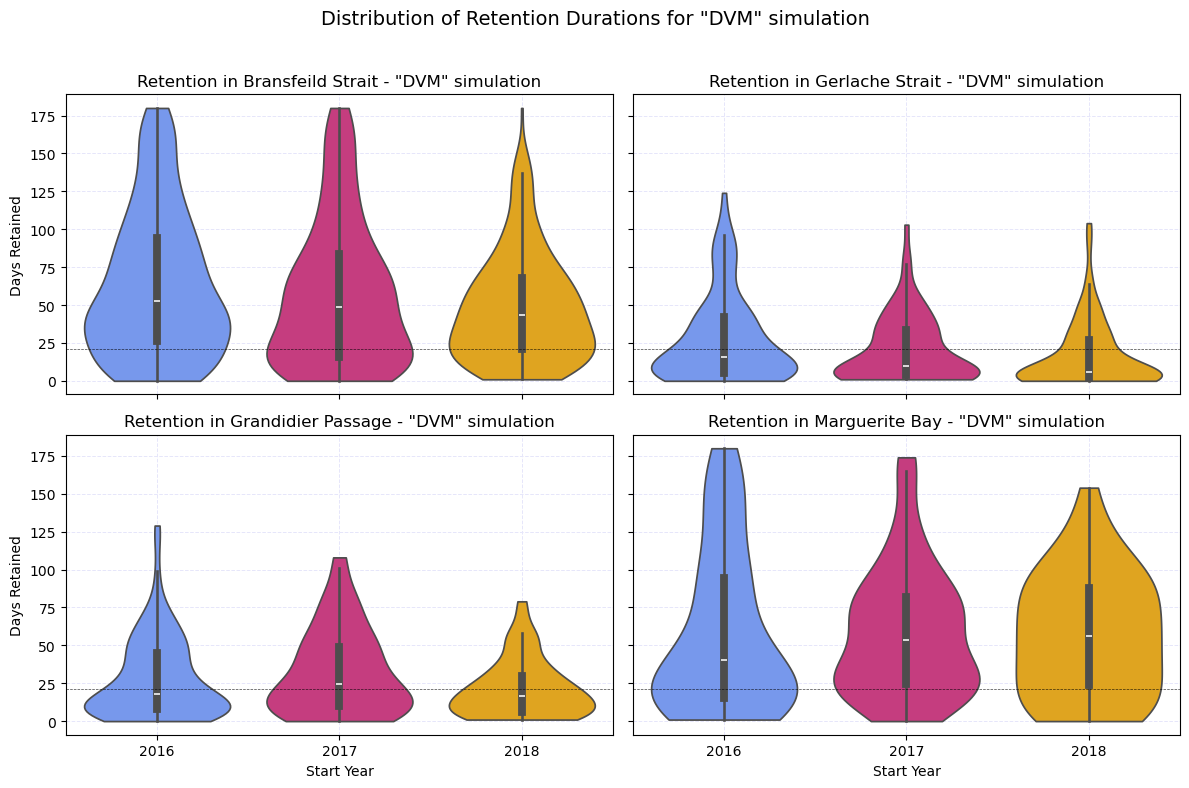

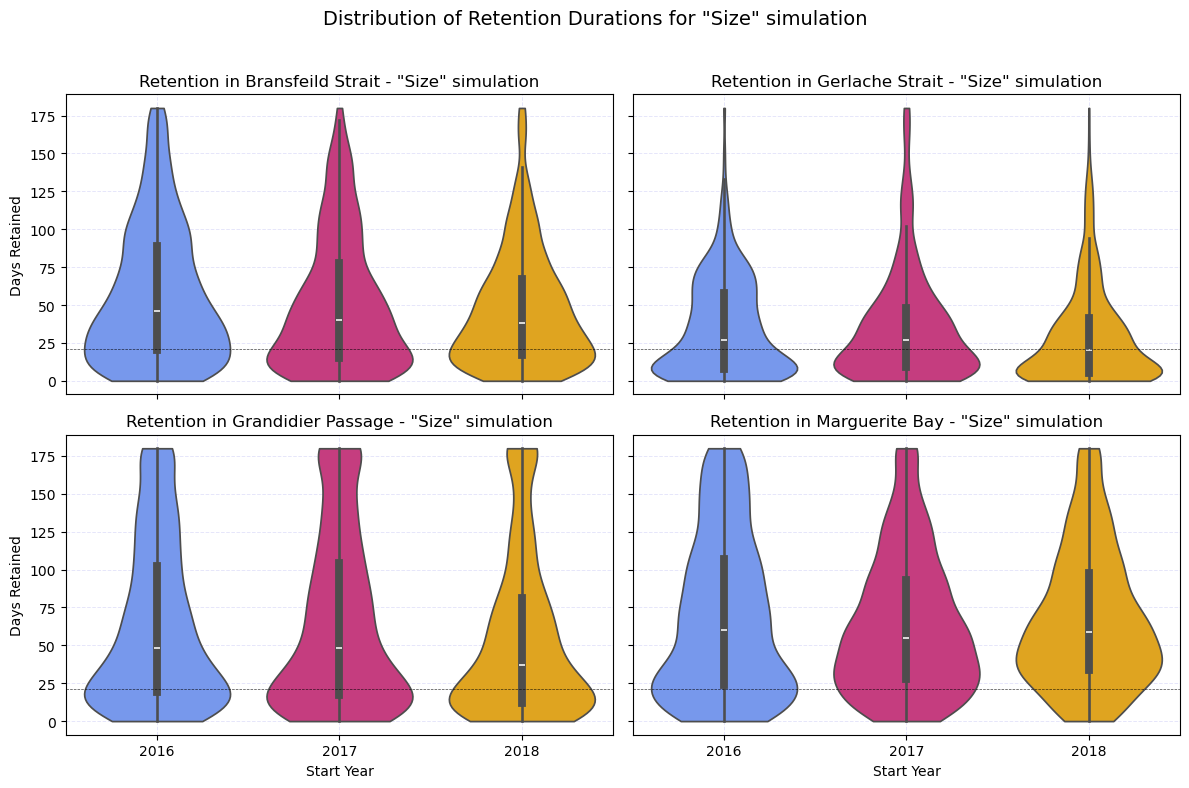

In [79]:
# Loop through all hypotheses
for hypothesis in hypotheses:
    plot_4_panel(hypothesis)

In [49]:
grouped_df

,hypothesis,start_year,IDL_loc,larval_id,BS,GERL,GP,MB2,outside
0,h_dvm,2016,BS,02_16_1_0001,28,0,0,0,152
1,h_dvm,2016,BS,02_16_1_0002,13,0,0,0,167
2,h_dvm,2016,BS,02_16_1_0003,47,52,0,0,81
3,h_dvm,2016,BS,02_16_1_0004,33,0,0,0,147
4,h_dvm,2016,BS,02_16_1_0005,102,0,0,0,78
...,...,...,...,...,...,...,...,...,...
16653,h_size,2018,MB2,03_18_4_1071,0,0,31,58,91
16654,h_size,2018,MB2,03_18_4_1072,0,0,81,87,12
16655,h_size,2018,MB2,03_18_4_1073,0,0,69,102,9
16656,h_size,2018,MB2,03_18_4_1074,0,0,39,82,59


# Life Stage

In [50]:
processed_df

,N,T,date,lat,lon,release,stage,larval_id,start_year,hypothesis,IDL_loc,BS,GERL,GP,MB2,outside
0,0,0,2016-11-01,-66.912544,287.83374,0,0,00_16_1_0001,2016,h_null,BS,False,False,False,False,True
1,0,1,2016-11-02,-66.830450,288.03165,0,0,00_16_1_0001,2016,h_null,BS,False,False,False,False,True
2,0,2,2016-11-03,-66.757600,288.15454,0,0,00_16_1_0001,2016,h_null,BS,False,False,False,False,True
3,0,3,2016-11-04,-66.711136,288.16013,0,0,00_16_1_0001,2016,h_null,BS,False,False,False,False,True
4,0,4,2016-11-05,-66.718590,288.06876,0,0,00_16_1_0001,2016,h_null,BS,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2998435,199,175,2019-09-12,-60.327457,306.02032,10,4,00_18_1_0200,2018,h_null,BS,False,False,False,False,True
2998436,199,176,2019-09-13,-60.238560,305.90730,10,4,00_18_1_0200,2018,h_null,BS,False,False,False,False,True
2998437,199,177,2019-09-14,-60.116886,305.83090,10,4,00_18_1_0200,2018,h_null,BS,False,False,False,False,True
2998438,199,178,2019-09-15,-60.023293,305.82330,10,4,00_18_1_0200,2018,h_null,BS,False,False,False,False,True


In [51]:
# Group by relevant identifiers and sum the presence counts
grouped_df_ls = processed_df.groupby(
    ['hypothesis', 'start_year', 'IDL_loc', 'larval_id','stage']
)[presence_columns].sum().reset_index()

print('Number of larvae after grouping:', grouped_df_ls.larval_id.nunique())

Number of larvae after grouping: 16658
